Step 1: Import Libraries and Load Data

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Load the data
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)

# Convert Month to datetime and set as index
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

print("Data Loaded Successfully!")
df.head()

Data Loaded Successfully!


,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


Step 2: Visualization

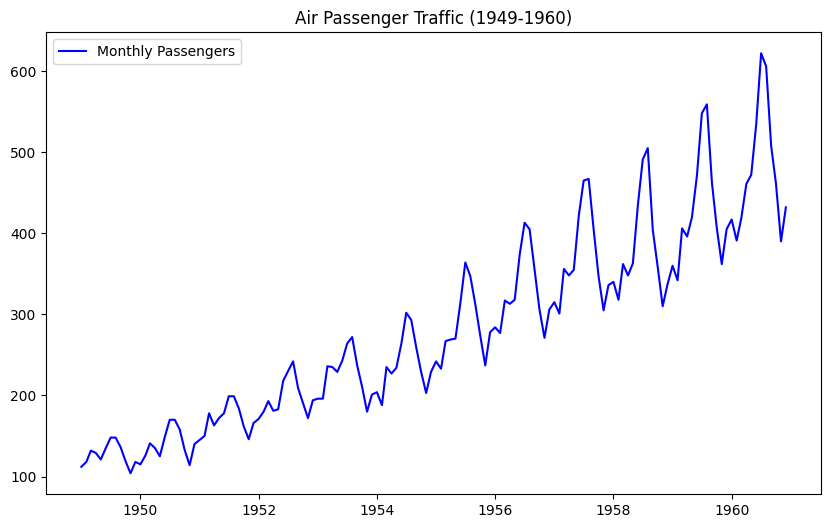

In [15]:
plt.figure(figsize=(10,6))
plt.plot(df, label='Monthly Passengers', color='blue')
plt.title('Air Passenger Traffic (1949-1960)')
plt.legend()
plt.show()

Step 3: Preprocessing

In [16]:
# Scale data (0 to 1)
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

# Create sequences (Use last 12 months to predict the next)
def create_dataset(dataset, look_back=12):
    X, Y = [], []
    for i in range(len(dataset)-look_back):
        X.append(dataset[i:(i+look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y) # Corrected variable name from Y to y

X, y = create_dataset(scaled_data, look_back=12)

# Split into 80% Train and 20% Test
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"Total samples: {len(X)}")
print(f"Training samples: {len(X_train)}")

Total samples: 132
Training samples: 105


Step 4: Training the Models

In [17]:
# 1. Random Forest (ML)
ml_model = RandomForestRegressor(n_estimators=100)
ml_model.fit(X_train, y_train)
ml_preds = ml_model.predict(X_test)

# 2. LSTM (Deep Learning) - Needs a 3D shape
X_train_dl = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_dl = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

dl_model = Sequential([
    LSTM(50, activation='relu', input_shape=(12, 1)),
    Dense(1)
])
dl_model.compile(optimizer='adam', loss='mse')
dl_model.fit(X_train_dl, y_train, epochs=100, batch_size=1, verbose=0)
dl_preds = dl_model.predict(X_test_dl)

print("Models Trained Successfully!")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
Models Trained Successfully!


Step 5: Final Comparison

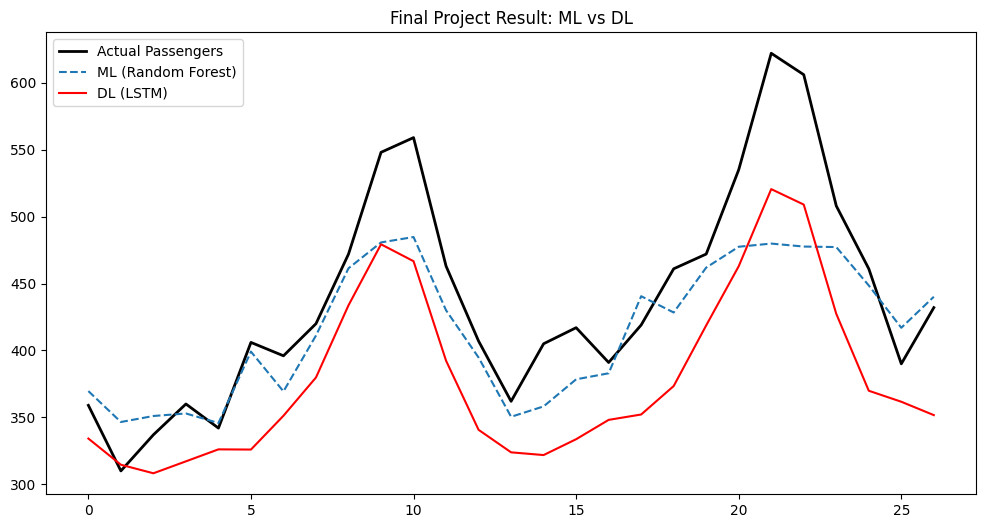

ML Average Error: 32.87 Passengers
DL Average Error: 60.16 Passengers


In [18]:
# Reverse scaling
actual = scaler.inverse_transform(y_test.reshape(-1, 1))
ml_final = scaler.inverse_transform(ml_preds.reshape(-1, 1))
dl_final = scaler.inverse_transform(dl_preds)

# Plot
plt.figure(figsize=(12,6))
plt.plot(actual, label='Actual Passengers', color='black', linewidth=2)
plt.plot(ml_final, label='ML (Random Forest)', linestyle='--')
plt.plot(dl_final, label='DL (LSTM)', color='red')
plt.title('Final Project Result: ML vs DL')
plt.legend()
plt.show()

# Print Error
print(f"ML Average Error: {mean_absolute_error(actual, ml_final):.2f} Passengers")
print(f"DL Average Error: {mean_absolute_error(actual, dl_final):.2f} Passengers")